In [1]:
import math
import torch
import numpy as np
import pandas as pd
import networkx as nx

def normalize_token_for_graph(s: str, lowercase: bool = True) -> str:
    if s is None:
        return ""
    s = str(s)
    s = s.replace("▁", " ")
    s = s.replace("Ġ", " ")
    s = s.replace("Ċ", "\n")
    s = s.strip()
    if lowercase:
        s = s.lower()
    return s

def build_graph_node_lookup(G, lowercase: bool = True):
    lookup = {}
    collisions = {}
    for n in G.nodes():
        key = normalize_token_for_graph(n, lowercase=lowercase)
        if key in lookup and lookup[key] != n:
            collisions.setdefault(key, set()).update([lookup[key], n])
        else:
            lookup[key] = n
    if collisions:
        print("[WARN] Collisioni dopo normalizzazione (max 10):")
        for k, vals in list(collisions.items())[:10]:
            print(f"  {k!r} -> {sorted(vals)}")
    return lookup


def compute_neighbor_mass_and_loss_for_record(
    rec,
    G,
    graph_lookup=None,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
):
    if graph_lookup is None:
        graph_lookup = build_graph_node_lookup(G, lowercase=lowercase)

    # NEW: usa anchor_token_str (fallback su vecchi nomi)
    observed_raw = (
        rec.get("anchor_token_str")
        or rec.get("input_token_str")
        or rec.get("last_input_token_str", "")
    )
    observed_norm = normalize_token_for_graph(observed_raw, lowercase=lowercase)

    if observed_norm not in graph_lookup:
        return {
            "ok": False,
            "reason": "observed_token_not_in_graph",
            "observed_raw": observed_raw,
            "observed_norm": observed_norm,
            "mass_topk": np.nan,
            "loss_topk": np.nan,
            "num_neighbors": 0,
            "num_matched": 0,
            "matched": [],
        }

    observed_node = graph_lookup[observed_norm]
    neighbors = list(G.neighbors(observed_node))
    neighbors_norm = {normalize_token_for_graph(n, lowercase=lowercase) for n in neighbors}
    neighbors_norm.discard("")

    preds = rec.get(topk_field) or []
    probs = rec.get(probs_field) or []

    mass = 0.0
    matched = []
    for pred_raw, p in zip(preds, probs):
        pred_norm = normalize_token_for_graph(pred_raw, lowercase=lowercase)
        if pred_norm in neighbors_norm:
            fp = float(p)
            mass += fp
            matched.append({"pred_raw": pred_raw, "pred_norm": pred_norm, "prob": fp})

    loss = float("inf") if mass <= 0.0 else -math.log(mass)

    return {
        "ok": True,
        "reason": None,
        "observed_raw": observed_raw,
        "observed_norm": observed_norm,
        "observed_node": observed_node,
        "neighbors_norm": sorted(neighbors_norm),
        "mass_topk": float(mass),
        "loss_topk": float(loss),
        "num_neighbors": int(len(neighbors_norm)),
        "num_matched": int(len(matched)),
        "matched": matched,
    }


def compute_neighbor_loss_over_records(records, G, topk_field="top_decoded", probs_field="top_probs", lowercase=True):
    graph_lookup = build_graph_node_lookup(G, lowercase=lowercase)
    rows = []
    valid_losses = []

    for rec in records:
        # NEW: usa anchor_pos_1based (fallback su vecchi nomi)
        pos1 = (
            rec.get("anchor_pos_1based")
            or rec.get("token_position_1based")
            or (rec.get("token_position_0based", 0) + 1 if rec.get("token_position_0based") is not None else None)
            or (rec.get("last_token_pos", 0) + 1)
        )

        res = compute_neighbor_mass_and_loss_for_record(
            rec, G,
            graph_lookup=graph_lookup,
            topk_field=topk_field,
            probs_field=probs_field,
            lowercase=lowercase,
        )

        row = {
            "token_position_1based": pos1,
            "line_index": rec.get("line_index"),
            "ok": res["ok"],
            "reason": res["reason"],
            "observed_raw": res["observed_raw"],
            "observed_norm": res["observed_norm"],
            "mass_topk": res["mass_topk"],
            "loss_topk": res["loss_topk"],
            "num_neighbors": res["num_neighbors"],
            "num_matched": res["num_matched"],
            "matched_preds": [m["pred_norm"] for m in res.get("matched", [])],
            "matched_probs": [m["prob"] for m in res.get("matched", [])],
        }
        rows.append(row)

        if res["ok"] and np.isfinite(res["loss_topk"]):
            valid_losses.append(res["loss_topk"])

    df = pd.DataFrame(rows).sort_values("token_position_1based", na_position="last").reset_index(drop=True)

    summary = {
        "num_records_total": len(records),
        "num_records_evaluable": int(df["ok"].sum()) if len(df) else 0,
        "mean_loss_topk": float(np.mean(valid_losses)) if valid_losses else np.nan,
        "median_loss_topk": float(np.median(valid_losses)) if valid_losses else np.nan,
        "mean_mass_topk": float(np.mean(df.loc[df["ok"], "mass_topk"])) if df["ok"].any() else np.nan,
    }
    return summary, df

In [2]:
from utils import load_graph_from_txt
from pathlib import Path
from vis import Plotter
import matplotlib.pyplot as plt
import numpy as np

Grid - #nodi: 15 #archi: 14


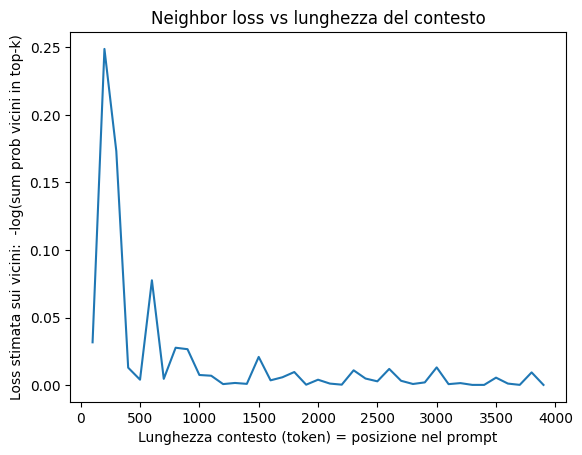

In [3]:
VOCAB_PATH = Path("../data/number_ids.txt")

grid_folder = "shuffled_tree_numbers"
structure_name = "bin_tree"

EMB_DIR    = Path(f"../embeddings/new/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="tree")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

# plt.figure(figsize=(8, 6))
# pos = nx.spring_layout(G, seed=0)  
# nx.draw(
#     G, pos,
#     with_labels=True,
#     node_size=600,
#     font_size=9
# )
# plt.show()


logit_file = EMB_DIR / f"final_topk_every100tok_bin_tree_numbers_shuffled_one_rw_2000.pt"

# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])


summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_tree_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

plt.figure()
plt.plot(shuffled_tree_numbers_loss[:, 0], shuffled_tree_numbers_loss[:, 1])
plt.xlabel("Lunghezza contesto (token) = posizione nel prompt")
plt.ylabel("Loss stimata sui vicini:  -log(sum prob vicini in top-k)")
plt.title("Neighbor loss vs lunghezza del contesto")
plt.show()

Grid - #nodi: 15 #archi: 14


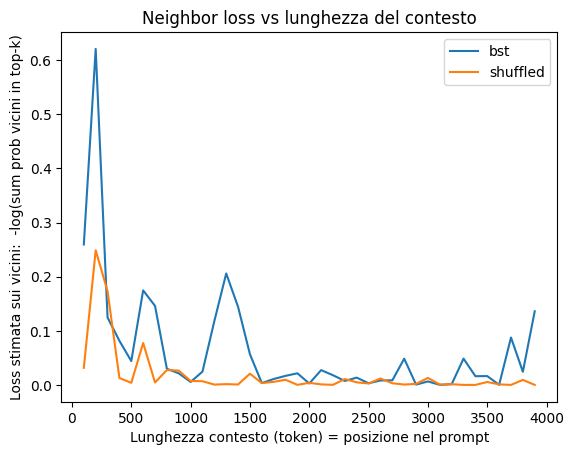

In [4]:
VOCAB_PATH = Path("../data/number_ids.txt")

grid_folder = "tree_numbers"
structure_name = "bin_tree"

EMB_DIR    = Path(f"../embeddings/new/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="tree")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

# plt.figure(figsize=(8, 6))
# pos = nx.spring_layout(G, seed=0)  
# nx.draw(
#     G, pos,
#     with_labels=True,
#     node_size=600,
#     font_size=9
# )
# plt.show()


logit_file = EMB_DIR / f"final_topk_every100tok_{structure_name}_one_rw_2000.pt"

# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])


summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

tree_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

plt.figure()
plt.plot(tree_numbers_loss[:, 0], tree_numbers_loss[:, 1], label="bst")
plt.plot(shuffled_tree_numbers_loss[:, 0], shuffled_tree_numbers_loss[:, 1], label="shuffled")
plt.legend()
plt.xlabel("Lunghezza contesto (token) = posizione nel prompt")
plt.ylabel("Loss stimata sui vicini:  -log(sum prob vicini in top-k)")
plt.title("Neighbor loss vs lunghezza del contesto")
plt.show()

Grid - #nodi: 15 #archi: 22


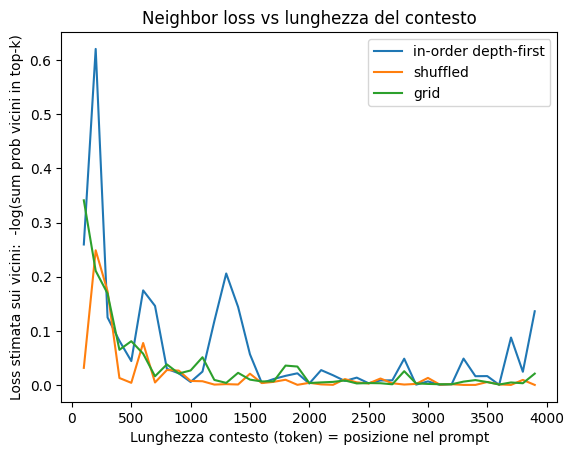

In [31]:
VOCAB_PATH = Path("../data/number_ids.txt")

grid_folder = "grid_numbers"
structure_name = "grid"

EMB_DIR    = Path(f"../embeddings/new/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="grid")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

# plt.figure(figsize=(8, 6))
# pos = nx.spring_layout(G, seed=0)  
# nx.draw(
#     G, pos,
#     with_labels=True,
#     node_size=600,
#     font_size=9
# )
# plt.show()


logit_file = EMB_DIR / f"final_topk_every100tok_{grid_folder}_one_rw_2000.pt"

# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])


summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

grid_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

plt.figure()
plt.plot(tree_numbers_loss[:, 0], tree_numbers_loss[:, 1], label="in-order depth-first")
plt.plot(shuffled_tree_numbers_loss[:, 0], shuffled_tree_numbers_loss[:, 1], label="shuffled")
plt.plot(grid_numbers_loss[:, 0], grid_numbers_loss[:, 1], label="grid")
plt.legend()
plt.xlabel("Lunghezza contesto (token) = posizione nel prompt")
plt.ylabel("Loss stimata sui vicini:  -log(sum prob vicini in top-k)")
plt.title("Neighbor loss vs lunghezza del contesto")
plt.show()

Grid - #nodi: 7 #archi: 7


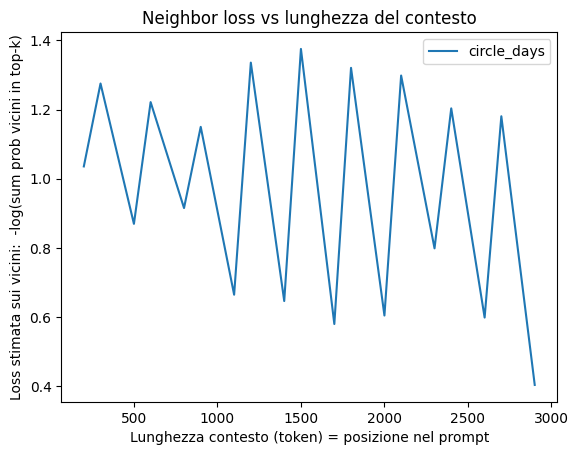

In [25]:
VOCAB_PATH = Path("../data/days_tkid_map.txt")

grid_folder = "circle_days"
structure_name = "circle"

EMB_DIR    = Path(f"../embeddings/new/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="cycle")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

# plt.figure(figsize=(8, 6))
# pos = nx.spring_layout(G, seed=0)  
# nx.draw(
#     G, pos,
#     with_labels=True,
#     node_size=600,
#     font_size=9
# )
# plt.show()



logit_file = EMB_DIR / f"final_topk_every100tok_circle_days_one_rw_2000.pt"

# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])



summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

circle_day = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

plt.figure()
plt.plot(circle_day[:, 0], circle_day[:, 1], label="circle_days")
plt.legend()
plt.xlabel("Lunghezza contesto (token) = posizione nel prompt")
plt.ylabel("Loss stimata sui vicini:  -log(sum prob vicini in top-k)")
plt.title("Neighbor loss vs lunghezza del contesto")
plt.show()

Grid - #nodi: 7 #archi: 6


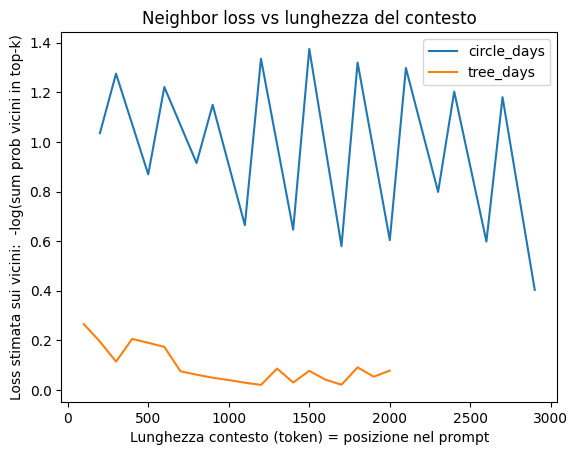

In [26]:
VOCAB_PATH = Path("../data/days_tkid_map.txt")

grid_folder = "tree_days"
structure_name = "bin_tree"

EMB_DIR    = Path(f"../embeddings/new/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="tree")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

# plt.figure(figsize=(8, 6))
# pos = nx.spring_layout(G, seed=0)  
# nx.draw(
#     G, pos,
#     with_labels=True,
#     node_size=600,
#     font_size=9
# )
# plt.show()



logit_file = EMB_DIR / f"final_topk_every100tok_bin_tree_days_dataset_2000.pt"

# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])



summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

tree_day = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

plt.figure()
plt.plot(circle_day[:, 0], circle_day[:, 1], label="circle_days")
plt.plot(tree_day[:, 0], tree_day[:, 1], label="tree_days")
plt.legend()
plt.xlabel("Lunghezza contesto (token) = posizione nel prompt")
plt.ylabel("Loss stimata sui vicini:  -log(sum prob vicini in top-k)")
plt.title("Neighbor loss vs lunghezza del contesto")
plt.show()

Processing line with 1000 pairs, using indices [0:1000]


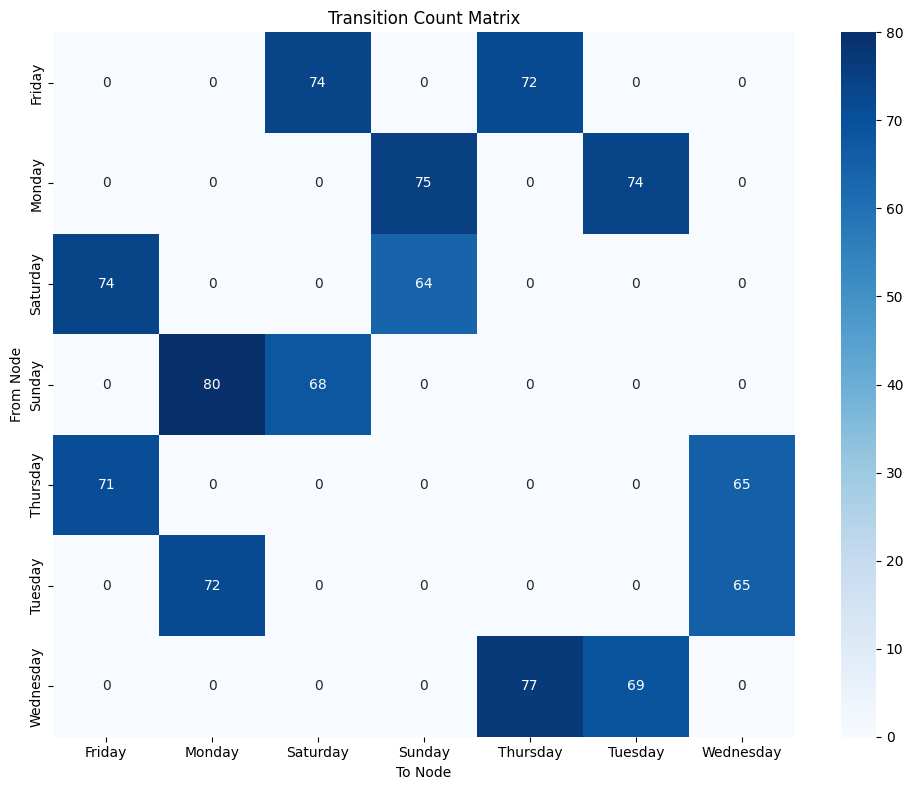

In [29]:
from utils import process_rw_file

_ , _ , _ = process_rw_file("../data/one_random_walk/circle_days/circle_days_one_rw_2000.txt")